# Employee Turnover - Exploratory Data Analysis (EDA)

This notebook provides a comprehensive analysis of the employee turnover dataset to understand:
- Data distribution and quality
- Key patterns in employee attrition
- Feature relationships with turnover
- Insights for model improvement

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
pd.set_option('display.max_columns', 50)

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded successfully!')

Libraries loaded successfully!


## 1. Data Loading & Overview

In [ ]:
# Load the data
df = pd.read_excel('first_file.xlsx')

print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"\nUnique Employees: {df['fictive2'].nunique()}")
print(f"Records per Employee: {df.shape[0] / df['fictive2'].nunique():.2f} (avg)")
df.head()

Dataset Shape: 4734 rows, 36 columns

Unique Employees: 1472
Records per Employee: 3.22 (avg)


,leave_ind,fictive-ovedmiun,fictive2,TeurGroupHscm,vetek_months,age,gender,EMP_Matzav_Mishpachti,distance_to_work,Yishuv,Semel_Yishuv,Seif,Maamad,tafkidCode,manager_Code,Tafkid,Maneger,Mahala,Distance,WorkHours,Sahar,MZV_Flag,hedrut,children,avg_Payment,stdevp_Payment,Median_Payment,change_in_salary_bySHKL,avg_illness,stdevp_illness,Median_illness,avg_omes,stdevp_omes,Median_omes,count_managers,turnover_prob
0,0,2,16975,חודשי,128,37,אישה,נשוי/נשואה,10,מגדל העמק,874.0,9002804.0,9,NaN,NaN,0,0,1,0,0,0,0,0,0,7450.0,0.0,7450.0,0.0,10.74,21.652808,0.00,0.85,0.139141,0.897805,0,0.166233
1,0,3,18077,חודשי,105,61,גבר,נשוי/נשואה,25,נצרת עילית,1061.0,9001421.0,9,NaN,NaN,0,0,0,0,0,0,0,0,0,5510.0,0.0,5510.0,0.0,3.50,11.608187,0.00,1.10,0.122349,1.109810,0,0.909536
2,0,4,18133,חודשי,105,52,אישה,נשוי/נשואה,25,נצרת עילית,1061.0,9001653.0,9,NaN,NaN,0,0,0,0,0,0,0,0,0,6130.0,0.0,6130.0,0.0,12.65,0.888968,12.92,1.24,0.100959,1.265375,0,0.405852
3,0,5,18189,חודשי,105,44,אישה,רווק/ה,25,נצרת עילית,1061.0,9001653.0,9,NaN,NaN,0,0,0,0,0,0,0,0,0,6280.0,0.0,6280.0,0.0,12.92,0.004714,12.92,1.10,0.171588,1.156985,0,0.152415
4,0,6,18245,חודשי,105,64,גבר,נשוי/נשואה,25,נצרת עילית,1061.0,9001120.0,9,NaN,NaN,0,0,1,0,0,0,0,0,0,5450.0,0.0,5450.0,0.0,49.43,68.538789,12.40,0.50,0.206492,0.910369,0,0.633560


In [ ]:
# Data types and info
print("Data Types Summary:")
print(df.dtypes.value_counts())
print("\nColumn Details:")
df.info()

Data Types Summary:
int64      17
float64    15
object      4
Name: count, dtype: int64

Column Details:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4734 entries, 0 to 4733
Data columns (total 36 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   leave_ind                4734 non-null   int64  
 1   fictive-ovedmiun         4734 non-null   int64  
 2   fictive2                 4734 non-null   int64  
 3   TeurGroupHscm            4578 non-null   object 
 4   vetek_months             4734 non-null   int64  
 5   age                      4734 non-null   int64  
 6   gender                   4734 non-null   object 
 7   EMP_Matzav_Mishpachti    4734 non-null   object 
 8   distance_to_work         4734 non-null   int64  
 9   Yishuv                   4726 non-null   object 
 10  Semel_Yishuv             4726 non-null   float64
 11  Seif                     4733 non-null   float64
 12  Maamad                   47

Columns with missing values: 16


,Missing Count,Missing %
manager_Code,2322,49.05
tafkidCode,2321,49.03
change_in_salary_bySHKL,1043,22.03
TeurGroupHscm,156,3.30
avg_omes,36,0.76
stdevp_omes,36,0.76
Median_omes,36,0.76
avg_Payment,11,0.23
Median_Payment,11,0.23
stdevp_Payment,11,0.23


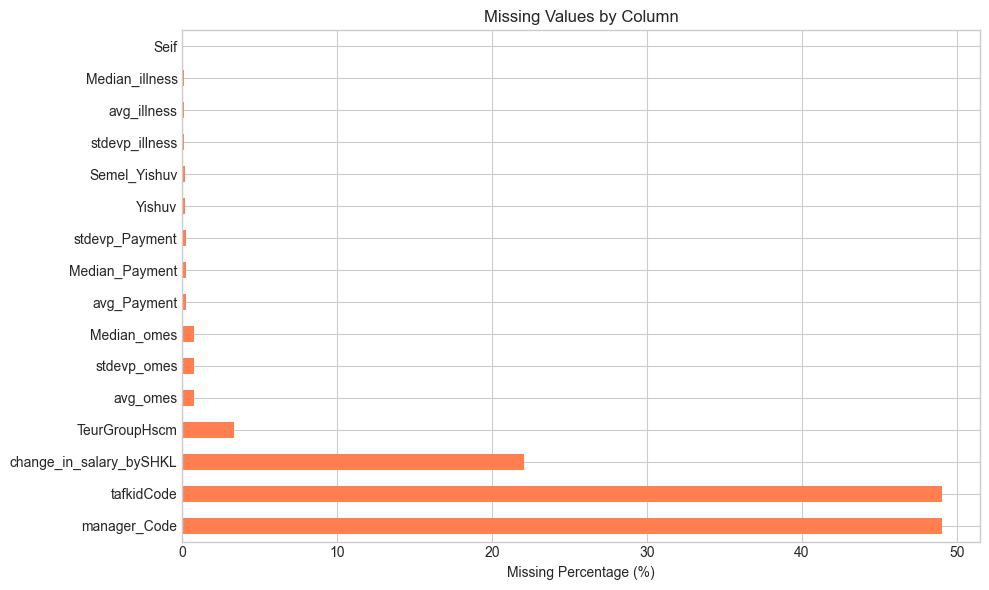

In [ ]:
# Missing values analysis
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

print(f"Columns with missing values: {len(missing_df)}")
display(missing_df)

# Visualize missing values
if len(missing_df) > 0:
    fig, ax = plt.subplots(figsize=(10, 6))
    missing_df['Missing %'].plot(kind='barh', ax=ax, color='coral')
    ax.set_xlabel('Missing Percentage (%)')
    ax.set_title('Missing Values by Column')
    plt.tight_layout()
    plt.show()

## 2. Target Variable Analysis

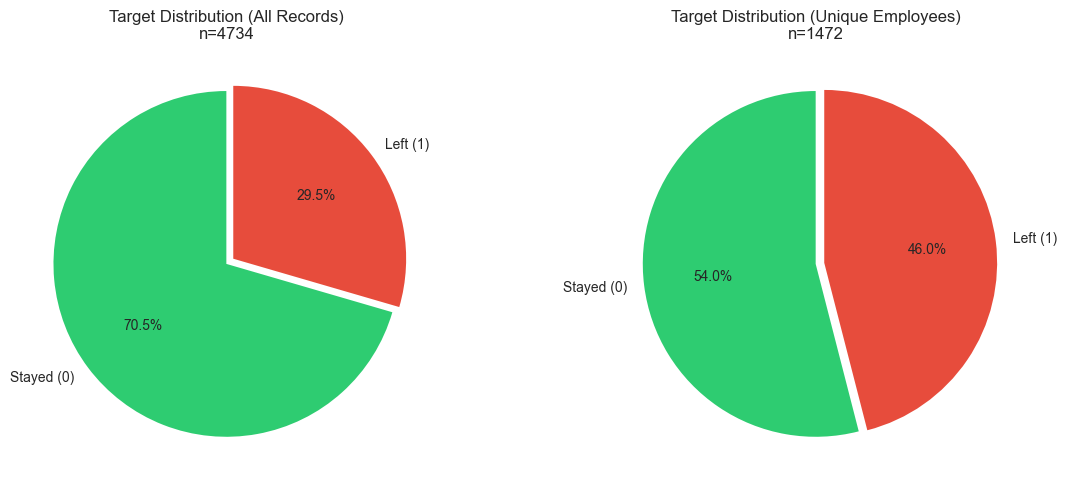


Class Balance (Unique Employees):
  Stayed: 795 (54.0%)
  Left:   677 (46.0%)


In [ ]:
# Target distribution (per record)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Per record
target_counts = df['leave_ind'].value_counts()
colors = ['#2ecc71', '#e74c3c']
axes[0].pie(target_counts, labels=['Stayed (0)', 'Left (1)'], autopct='%1.1f%%', 
            colors=colors, explode=[0, 0.05], startangle=90)
axes[0].set_title(f'Target Distribution (All Records)\nn={len(df)}')

# Per unique employee
emp_target = df.groupby('fictive2')['leave_ind'].last()
emp_counts = emp_target.value_counts()
axes[1].pie(emp_counts, labels=['Stayed (0)', 'Left (1)'], autopct='%1.1f%%', 
            colors=colors, explode=[0, 0.05], startangle=90)
axes[1].set_title(f'Target Distribution (Unique Employees)\nn={len(emp_target)}')

plt.tight_layout()
plt.show()

print(f"\nClass Balance (Unique Employees):")
print(f"  Stayed: {emp_counts[0]} ({emp_counts[0]/len(emp_target)*100:.1f}%)")
print(f"  Left:   {emp_counts[1]} ({emp_counts[1]/len(emp_target)*100:.1f}%)")

## 3. Numerical Features Analysis

In [ ]:
# Key numerical features
numeric_cols = ['vetek_months', 'age', 'distance_to_work', 'avg_Payment', 'Median_Payment',
                'avg_illness', 'avg_omes', 'count_managers', 'change_in_salary_bySHKL']

# Summary statistics
print("Numerical Features Summary Statistics:")
df[numeric_cols].describe().round(2)

Numerical Features Summary Statistics:


,vetek_months,age,distance_to_work,avg_Payment,Median_Payment,avg_illness,avg_omes,count_managers,change_in_salary_bySHKL
count,4734.00,4734.00,4734.00,4723.00,4723.00,4729.00,4698.00,4734.00,3691.00
mean,90.14,46.76,24.52,8561.12,8559.21,5.88,1.00,0.13,320.43
std,102.60,12.56,14.61,7721.60,7732.64,7.03,0.18,0.44,976.72
min,0.00,16.00,9.00,22.98,22.98,0.00,0.06,0.00,-9085.50
25%,13.00,37.00,10.00,5508.00,5500.00,0.00,0.90,0.00,0.00
50%,48.00,48.00,22.00,6370.00,6370.00,4.06,0.99,0.00,0.00
75%,136.00,57.00,31.00,10956.25,11000.00,9.07,1.11,0.00,350.00
max,528.00,79.00,176.00,90000.00,90000.00,72.98,1.63,3.00,20878.00


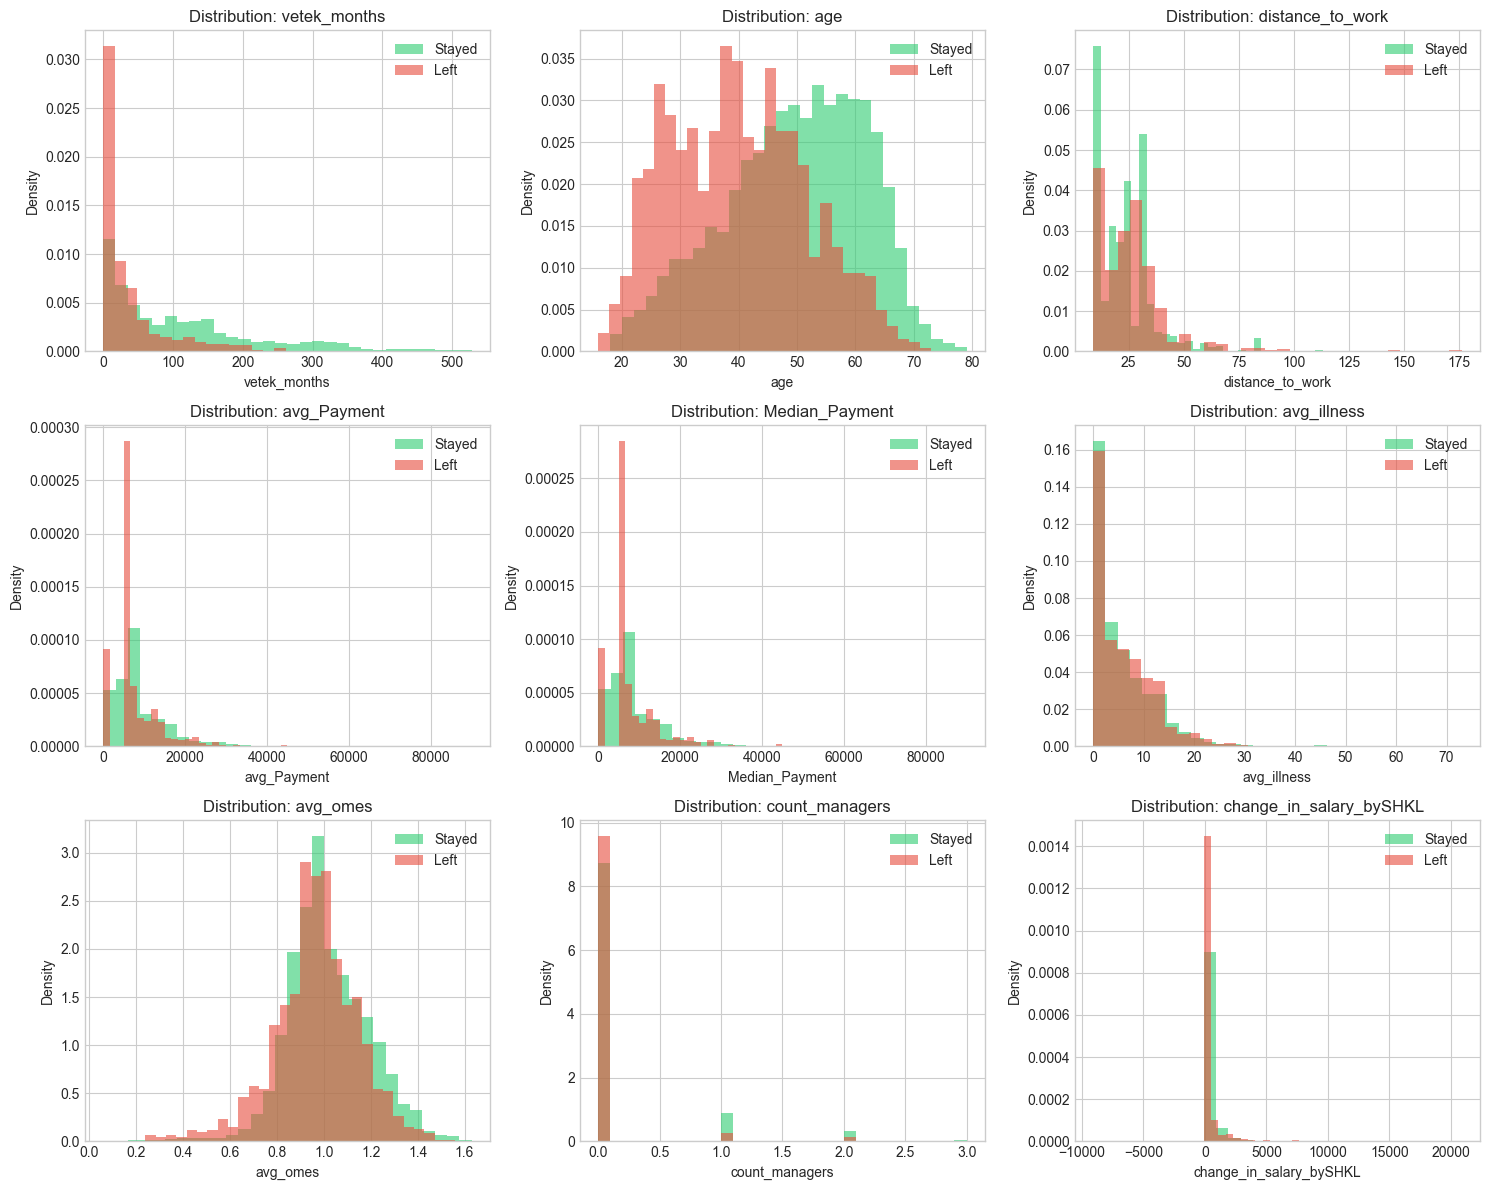

In [ ]:
# Distribution plots for key numeric features
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    ax = axes[i]
    
    # Plot by target
    for target, color, label in [(0, '#2ecc71', 'Stayed'), (1, '#e74c3c', 'Left')]:
        data = df[df['leave_ind'] == target][col].dropna()
        ax.hist(data, bins=30, alpha=0.6, color=color, label=label, density=True)
    
    ax.set_xlabel(col)
    ax.set_ylabel('Density')
    ax.legend()
    ax.set_title(f'Distribution: {col}')

plt.tight_layout()
plt.show()

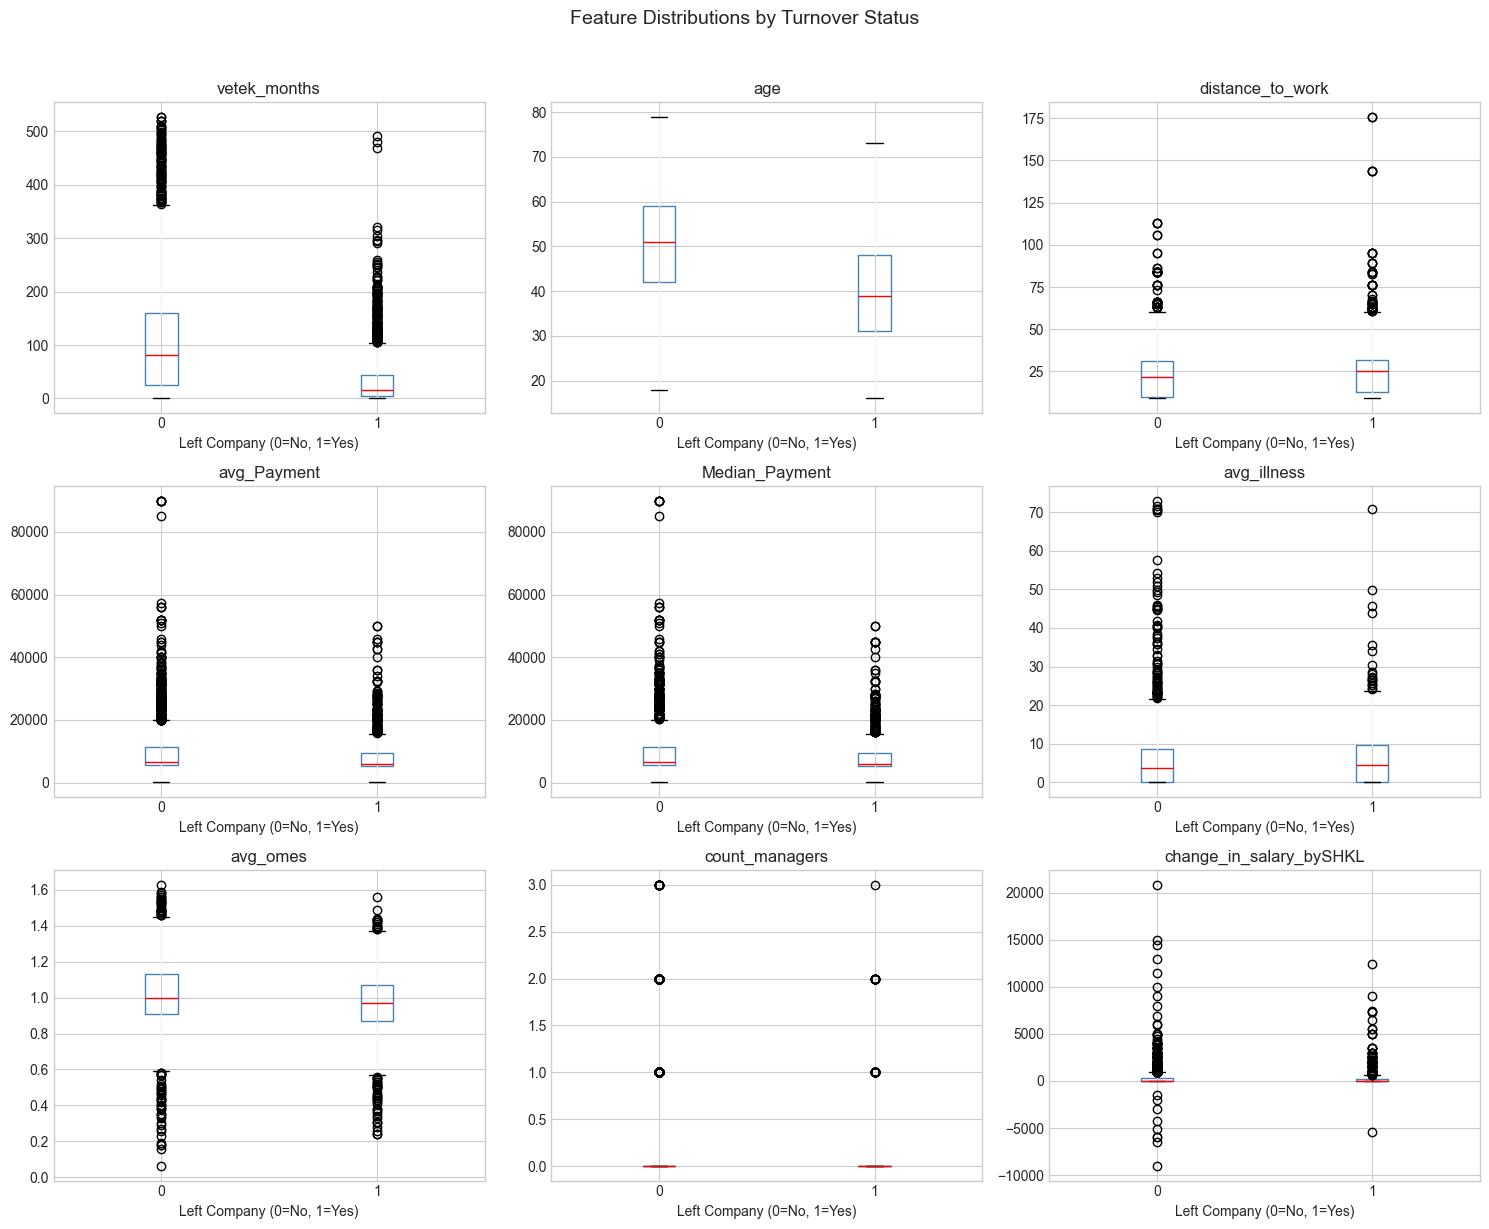

In [ ]:
# Box plots comparing features by target
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    ax = axes[i]
    df.boxplot(column=col, by='leave_ind', ax=ax, 
               boxprops=dict(color='steelblue'),
               medianprops=dict(color='red'))
    ax.set_xlabel('Left Company (0=No, 1=Yes)')
    ax.set_title(col)

plt.suptitle('Feature Distributions by Turnover Status', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# Statistical test: Are features significantly different between groups?
print("Statistical Significance Test (Mann-Whitney U Test)")
print("="*60)

results = []
for col in numeric_cols:
    stayed = df[df['leave_ind'] == 0][col].dropna()
    left = df[df['leave_ind'] == 1][col].dropna()
    
    stat, pval = stats.mannwhitneyu(stayed, left, alternative='two-sided')
    
    results.append({
        'Feature': col,
        'Stayed Mean': stayed.mean(),
        'Left Mean': left.mean(),
        'Difference': left.mean() - stayed.mean(),
        'p-value': pval,
        'Significant': '✓' if pval < 0.05 else '✗'
    })

results_df = pd.DataFrame(results).sort_values('p-value')
display(results_df.round(4))

Statistical Significance Test (Mann-Whitney U Test)


,Feature,Stayed Mean,Left Mean,Difference,p-value,Significant
0,vetek_months,111.9589,38.0215,-73.9375,0.0000,✓
1,age,49.6758,39.8039,-9.8719,0.0000,✓
7,count_managers,0.1675,0.0558,-0.1117,0.0000,✓
3,avg_Payment,8893.4610,7767.4548,-1126.0062,0.0000,✓
4,Median_Payment,8886.6963,7777.1547,-1109.5416,0.0000,✓
6,avg_omes,1.0173,0.9653,-0.0520,0.0000,✓
8,change_in_salary_bySHKL,320.4416,320.3976,-0.0439,0.0000,✓
2,distance_to_work,23.8846,26.0315,2.1469,0.0000,✓
5,avg_illness,5.8460,5.9744,0.1283,0.1375,✗


## 4. Categorical Features Analysis

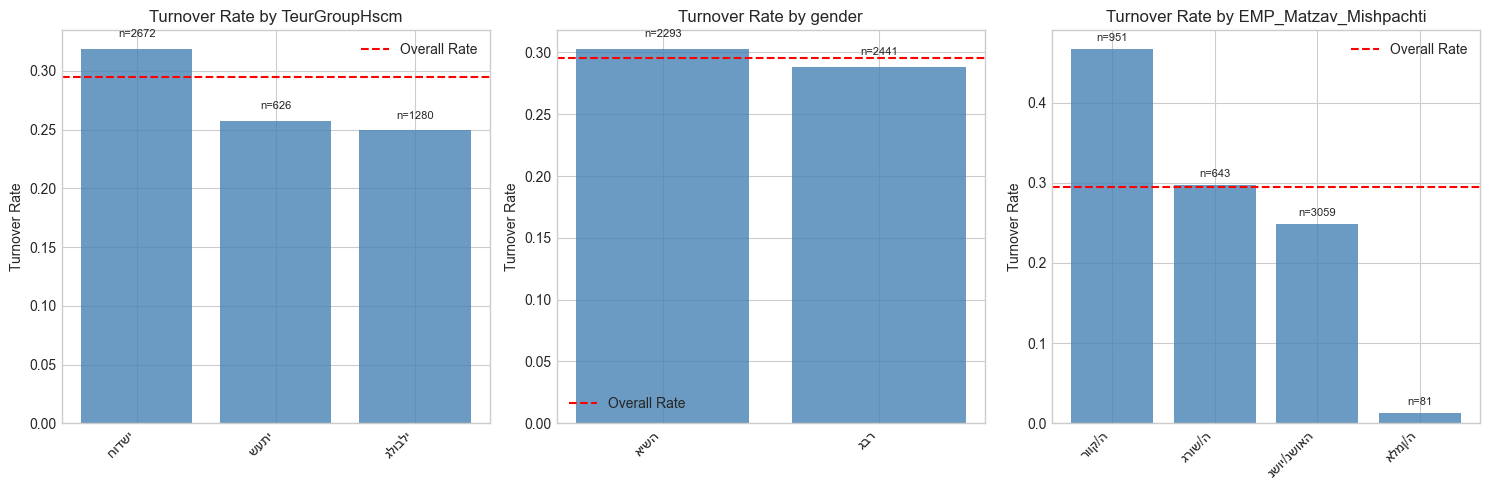

In [ ]:
# Categorical features
cat_cols = ['TeurGroupHscm', 'gender', 'EMP_Matzav_Mishpachti']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, col in enumerate(cat_cols):
    ax = axes[i]
    
    # Calculate turnover rate by category
    turnover_rate = df.groupby(col)['leave_ind'].mean().sort_values(ascending=False)
    counts = df.groupby(col).size()
    
    bars = ax.bar(range(len(turnover_rate)), turnover_rate.values, color='steelblue', alpha=0.8)
    ax.set_xticks(range(len(turnover_rate)))
    ax.set_xticklabels(turnover_rate.index, rotation=45, ha='right')
    ax.set_ylabel('Turnover Rate')
    ax.set_title(f'Turnover Rate by {col}')
    ax.axhline(y=df['leave_ind'].mean(), color='red', linestyle='--', label='Overall Rate')
    ax.legend()
    
    # Add count labels
    for j, (bar, idx) in enumerate(zip(bars, turnover_rate.index)):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                f'n={counts[idx]}', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

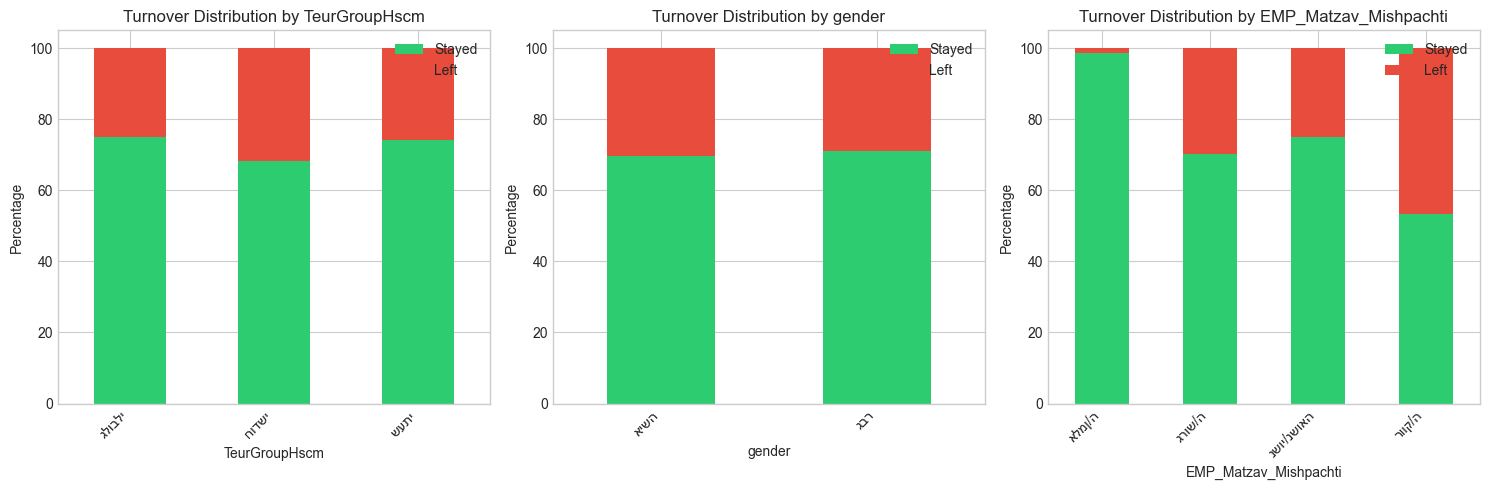

In [ ]:
# Detailed breakdown with stacked bars
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, col in enumerate(cat_cols):
    ax = axes[i]
    
    cross_tab = pd.crosstab(df[col], df['leave_ind'], normalize='index') * 100
    cross_tab.plot(kind='bar', stacked=True, ax=ax, color=['#2ecc71', '#e74c3c'])
    
    ax.set_xlabel(col)
    ax.set_ylabel('Percentage')
    ax.set_title(f'Turnover Distribution by {col}')
    ax.legend(['Stayed', 'Left'], loc='upper right')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

## 5. Correlation Analysis

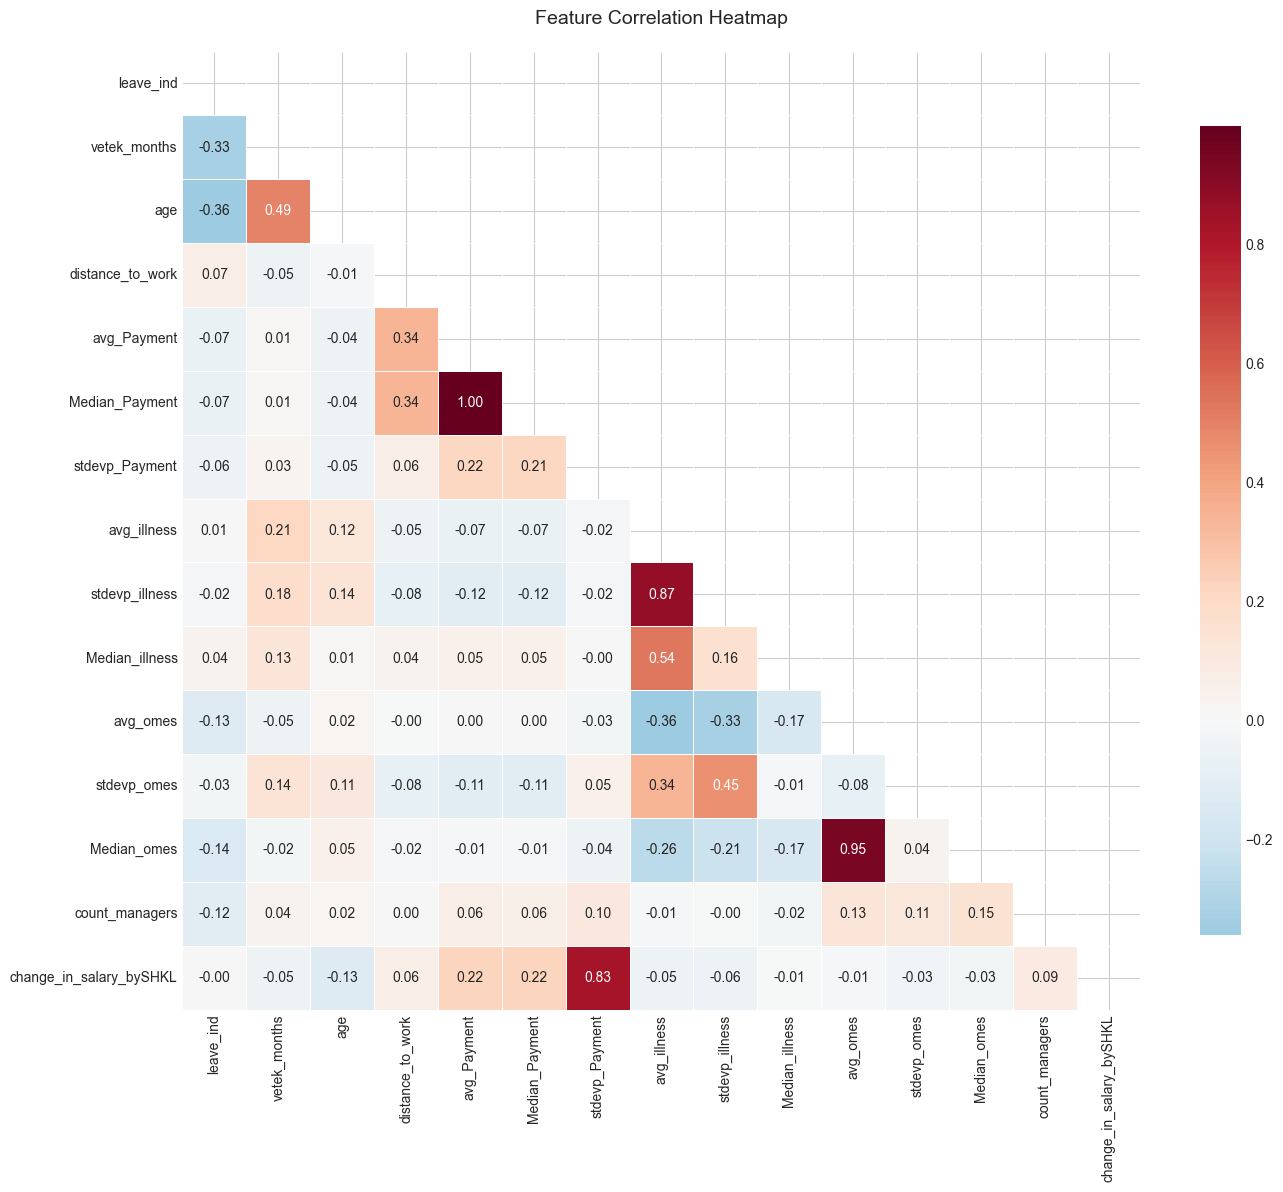

In [ ]:
# Select numeric columns for correlation
corr_cols = ['leave_ind', 'vetek_months', 'age', 'distance_to_work', 
             'avg_Payment', 'Median_Payment', 'stdevp_Payment',
             'avg_illness', 'stdevp_illness', 'Median_illness',
             'avg_omes', 'stdevp_omes', 'Median_omes', 
             'count_managers', 'change_in_salary_bySHKL']

corr_matrix = df[corr_cols].corr()

# Heatmap
fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', 
            center=0, ax=ax, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Heatmap', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

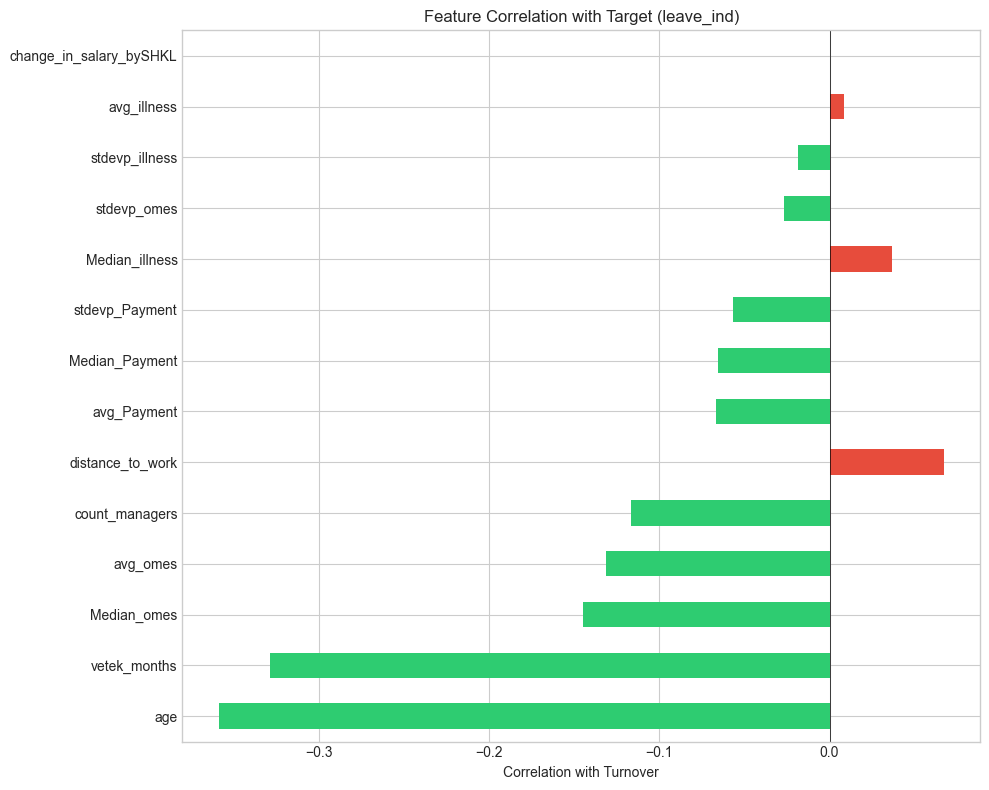


Top Positive Correlations (Higher = More Likely to Leave):
distance_to_work    0.067032
Median_illness      0.036902
avg_illness         0.008328
Name: leave_ind, dtype: float64

Top Negative Correlations (Higher = More Likely to Stay):
age              -0.358563
vetek_months     -0.328712
Median_omes      -0.144937
avg_omes         -0.131333
count_managers   -0.116352
Name: leave_ind, dtype: float64


In [ ]:
# Correlation with target
target_corr = corr_matrix['leave_ind'].drop('leave_ind').sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#e74c3c' if x > 0 else '#2ecc71' for x in target_corr.values]
target_corr.plot(kind='barh', ax=ax, color=colors)
ax.set_xlabel('Correlation with Turnover')
ax.set_title('Feature Correlation with Target (leave_ind)')
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.show()

print("\nTop Positive Correlations (Higher = More Likely to Leave):")
print(target_corr[target_corr > 0].head())
print("\nTop Negative Correlations (Higher = More Likely to Stay):")
print(target_corr[target_corr < 0].head())

## 6. Time-Series Analysis (Employee Tracking)

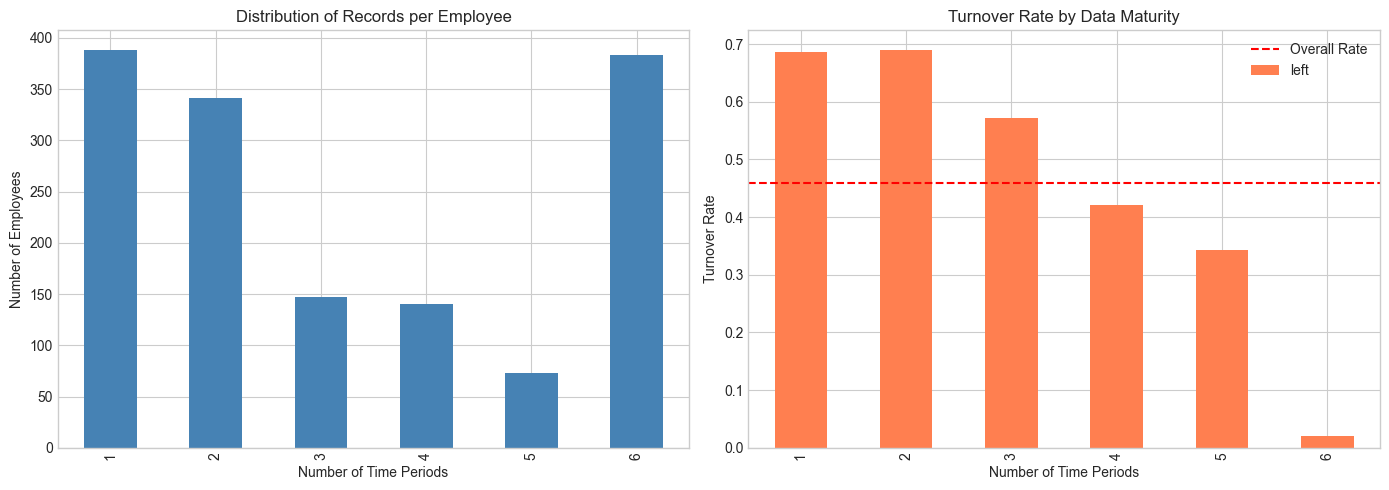


Records per Employee Statistics:
count    1472.000000
mean        3.216033
std         1.969050
min         1.000000
25%         1.000000
50%         3.000000
75%         6.000000
max         6.000000
dtype: float64


In [ ]:
# Analyze number of records per employee
records_per_emp = df.groupby('fictive2').size()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of records per employee
ax = axes[0]
records_per_emp.value_counts().sort_index().plot(kind='bar', ax=ax, color='steelblue')
ax.set_xlabel('Number of Time Periods')
ax.set_ylabel('Number of Employees')
ax.set_title('Distribution of Records per Employee')

# Turnover rate by number of records
ax = axes[1]
emp_records = df.groupby('fictive2').agg({'leave_ind': 'last', 'fictive-ovedmiun': 'count'})
emp_records.columns = ['left', 'num_periods']
turnover_by_periods = emp_records.groupby('num_periods')['left'].mean()

turnover_by_periods.plot(kind='bar', ax=ax, color='coral')
ax.set_xlabel('Number of Time Periods')
ax.set_ylabel('Turnover Rate')
ax.set_title('Turnover Rate by Data Maturity')
ax.axhline(y=emp_records['left'].mean(), color='red', linestyle='--', label='Overall Rate')
ax.legend()

plt.tight_layout()
plt.show()

print(f"\nRecords per Employee Statistics:")
print(records_per_emp.describe())

## 7. Age & Tenure Analysis

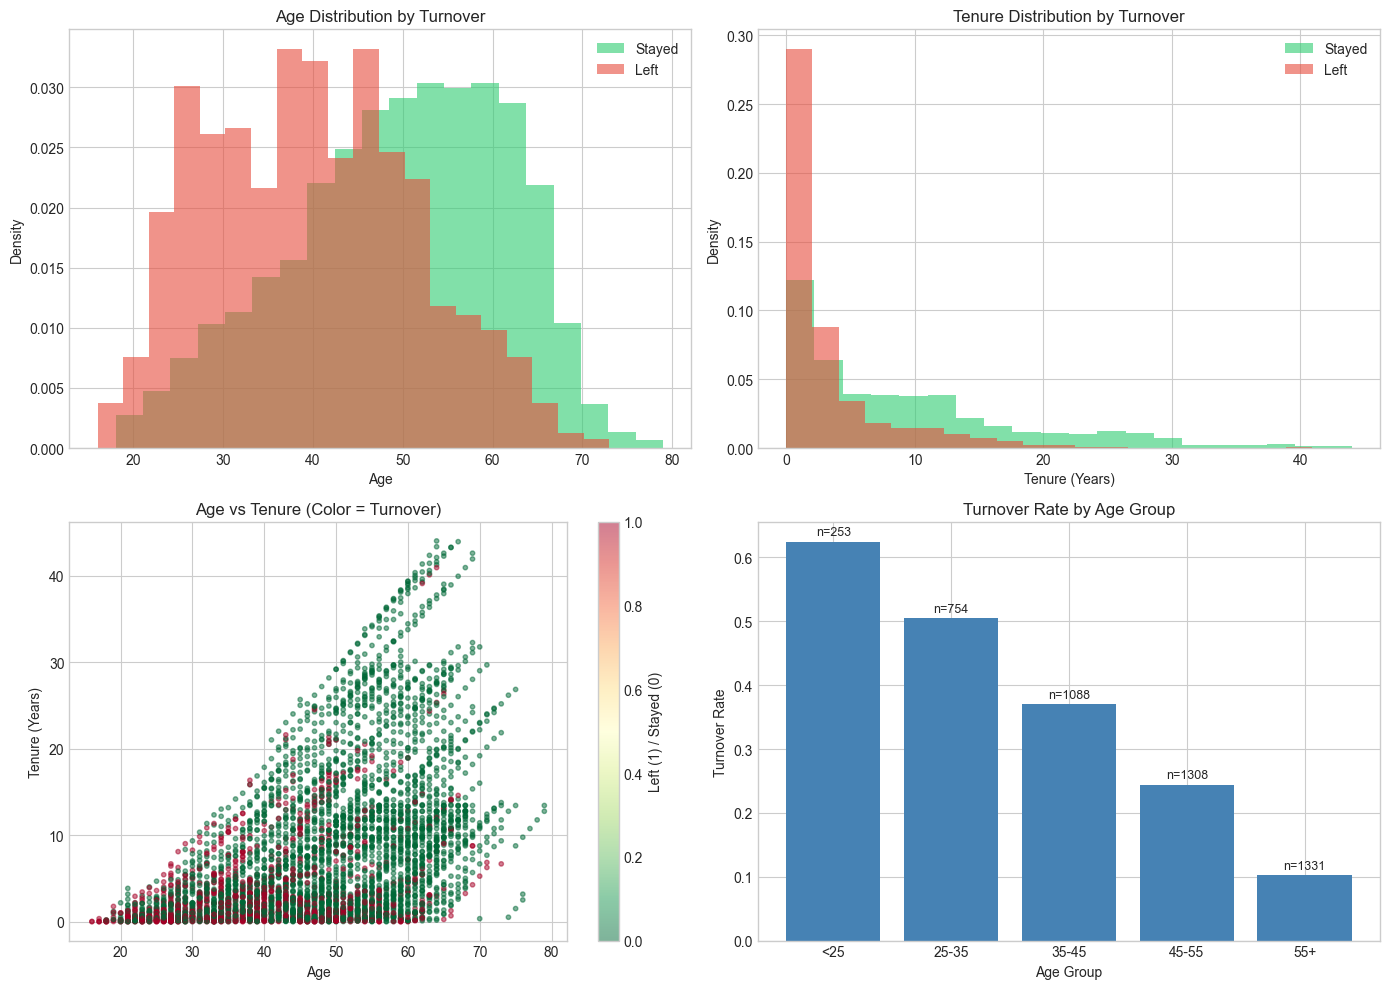

In [ ]:
# Age distribution by turnover
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Age distribution
ax = axes[0, 0]
for target, color, label in [(0, '#2ecc71', 'Stayed'), (1, '#e74c3c', 'Left')]:
    data = df[df['leave_ind'] == target]['age']
    ax.hist(data, bins=20, alpha=0.6, color=color, label=label, density=True)
ax.set_xlabel('Age')
ax.set_ylabel('Density')
ax.set_title('Age Distribution by Turnover')
ax.legend()

# Tenure distribution
ax = axes[0, 1]
for target, color, label in [(0, '#2ecc71', 'Stayed'), (1, '#e74c3c', 'Left')]:
    data = df[df['leave_ind'] == target]['vetek_months'] / 12  # Convert to years
    ax.hist(data, bins=20, alpha=0.6, color=color, label=label, density=True)
ax.set_xlabel('Tenure (Years)')
ax.set_ylabel('Density')
ax.set_title('Tenure Distribution by Turnover')
ax.legend()

# Age vs Tenure scatter
ax = axes[1, 0]
scatter = ax.scatter(df['age'], df['vetek_months']/12, c=df['leave_ind'], 
                     cmap='RdYlGn_r', alpha=0.5, s=10)
ax.set_xlabel('Age')
ax.set_ylabel('Tenure (Years)')
ax.set_title('Age vs Tenure (Color = Turnover)')
plt.colorbar(scatter, ax=ax, label='Left (1) / Stayed (0)')

# Turnover rate by age group
ax = axes[1, 1]
df['age_group'] = pd.cut(df['age'], bins=[0, 25, 35, 45, 55, 100], 
                         labels=['<25', '25-35', '35-45', '45-55', '55+'])
turnover_by_age = df.groupby('age_group', observed=True)['leave_ind'].agg(['mean', 'count'])

bars = ax.bar(range(len(turnover_by_age)), turnover_by_age['mean'], color='steelblue')
ax.set_xticks(range(len(turnover_by_age)))
ax.set_xticklabels(turnover_by_age.index)
ax.set_xlabel('Age Group')
ax.set_ylabel('Turnover Rate')
ax.set_title('Turnover Rate by Age Group')

for i, (bar, count) in enumerate(zip(bars, turnover_by_age['count'])):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
            f'n={count}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

## 8. Salary Analysis

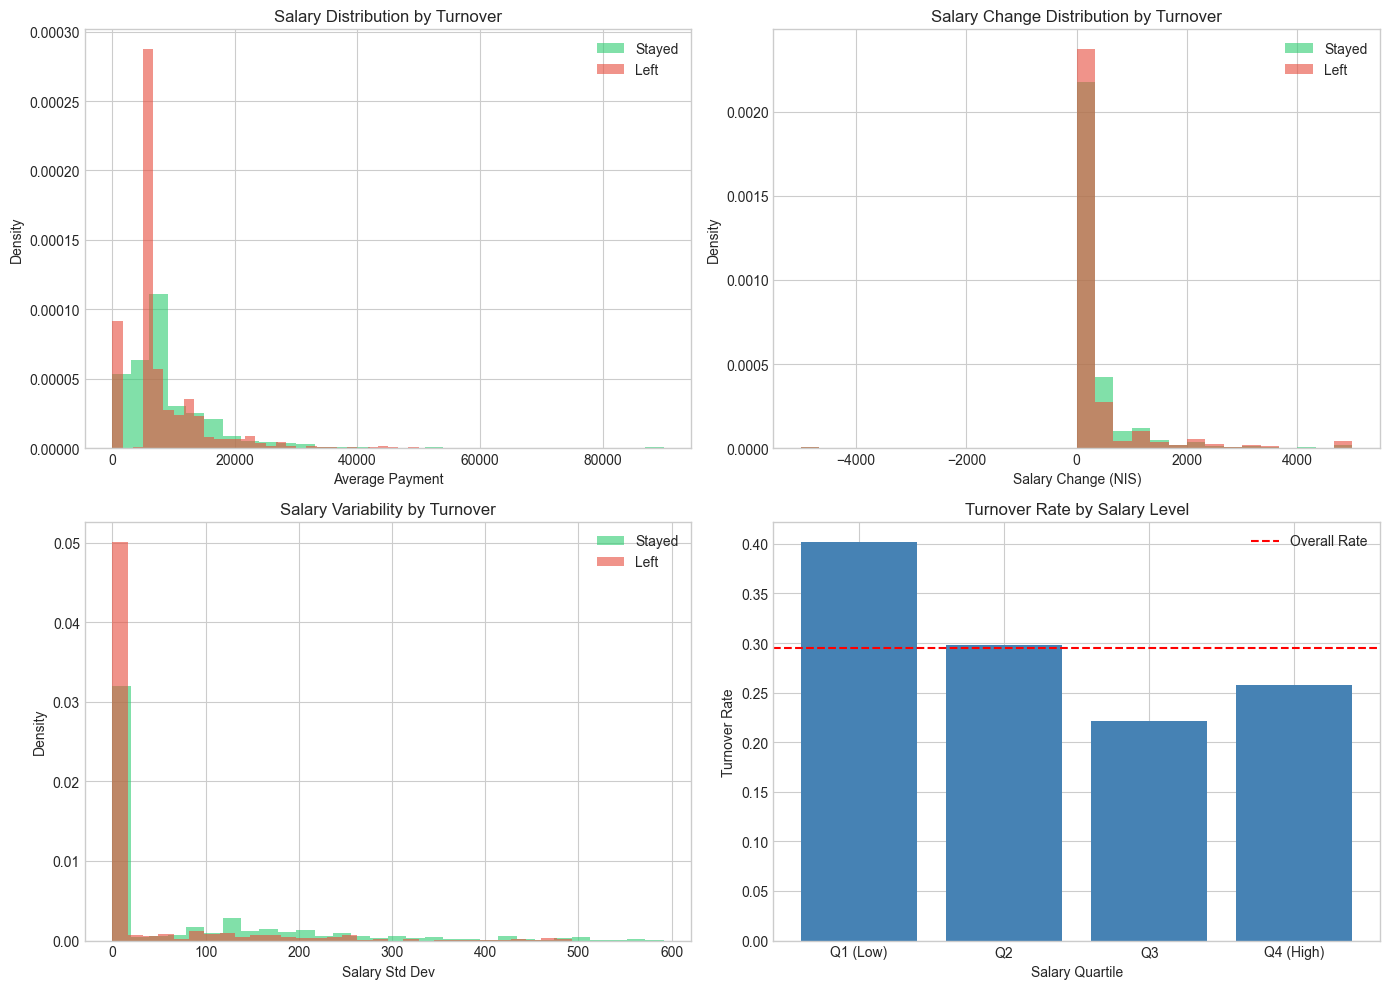

In [ ]:
# Salary analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Average Payment distribution
ax = axes[0, 0]
for target, color, label in [(0, '#2ecc71', 'Stayed'), (1, '#e74c3c', 'Left')]:
    data = df[df['leave_ind'] == target]['avg_Payment'].dropna()
    ax.hist(data, bins=30, alpha=0.6, color=color, label=label, density=True)
ax.set_xlabel('Average Payment')
ax.set_ylabel('Density')
ax.set_title('Salary Distribution by Turnover')
ax.legend()

# Salary change distribution
ax = axes[0, 1]
for target, color, label in [(0, '#2ecc71', 'Stayed'), (1, '#e74c3c', 'Left')]:
    data = df[df['leave_ind'] == target]['change_in_salary_bySHKL'].dropna()
    # Clip for visualization
    data = data.clip(-5000, 5000)
    ax.hist(data, bins=30, alpha=0.6, color=color, label=label, density=True)
ax.set_xlabel('Salary Change (NIS)')
ax.set_ylabel('Density')
ax.set_title('Salary Change Distribution by Turnover')
ax.legend()

# Salary variability (stddev)
ax = axes[1, 0]
for target, color, label in [(0, '#2ecc71', 'Stayed'), (1, '#e74c3c', 'Left')]:
    data = df[df['leave_ind'] == target]['stdevp_Payment'].dropna()
    data = data[data < data.quantile(0.95)]  # Remove extreme outliers
    ax.hist(data, bins=30, alpha=0.6, color=color, label=label, density=True)
ax.set_xlabel('Salary Std Dev')
ax.set_ylabel('Density')
ax.set_title('Salary Variability by Turnover')
ax.legend()

# Turnover by salary quartile
ax = axes[1, 1]
df['salary_quartile'] = pd.qcut(df['avg_Payment'].fillna(df['avg_Payment'].median()), 
                                 q=4, labels=['Q1 (Low)', 'Q2', 'Q3', 'Q4 (High)'])
turnover_by_salary = df.groupby('salary_quartile', observed=True)['leave_ind'].agg(['mean', 'count'])

bars = ax.bar(range(len(turnover_by_salary)), turnover_by_salary['mean'], color='steelblue')
ax.set_xticks(range(len(turnover_by_salary)))
ax.set_xticklabels(turnover_by_salary.index)
ax.set_xlabel('Salary Quartile')
ax.set_ylabel('Turnover Rate')
ax.set_title('Turnover Rate by Salary Level')
ax.axhline(y=df['leave_ind'].mean(), color='red', linestyle='--', label='Overall Rate')
ax.legend()

plt.tight_layout()
plt.show()

## 9. Workload & Sick Days Analysis

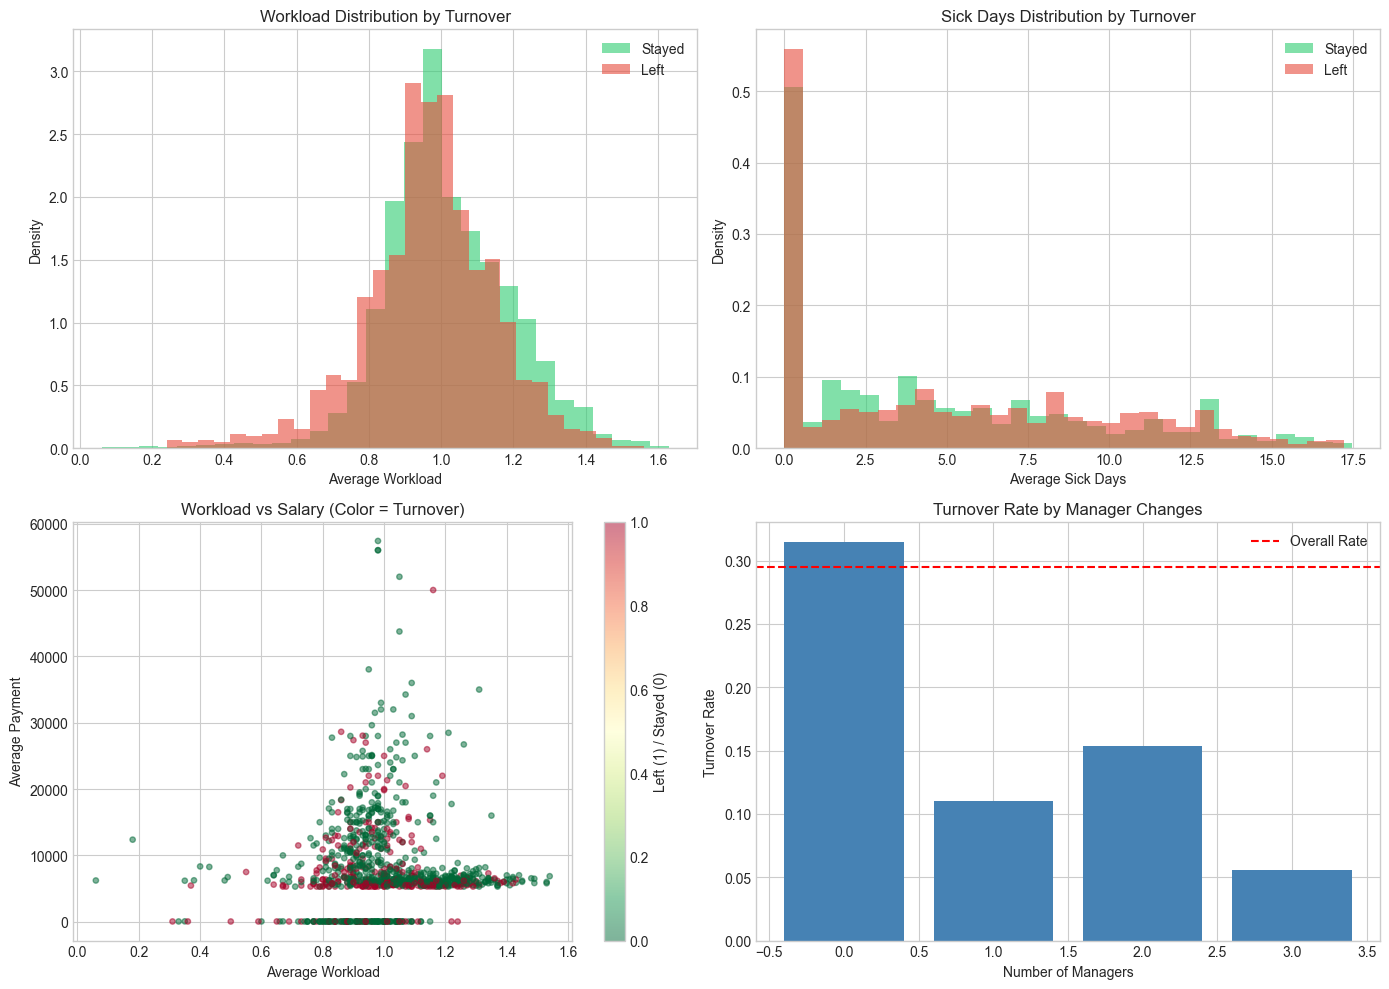

In [ ]:
# Workload and illness patterns
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Average Workload
ax = axes[0, 0]
for target, color, label in [(0, '#2ecc71', 'Stayed'), (1, '#e74c3c', 'Left')]:
    data = df[df['leave_ind'] == target]['avg_omes'].dropna()
    ax.hist(data, bins=30, alpha=0.6, color=color, label=label, density=True)
ax.set_xlabel('Average Workload')
ax.set_ylabel('Density')
ax.set_title('Workload Distribution by Turnover')
ax.legend()

# Average Sick Days
ax = axes[0, 1]
for target, color, label in [(0, '#2ecc71', 'Stayed'), (1, '#e74c3c', 'Left')]:
    data = df[df['leave_ind'] == target]['avg_illness'].dropna()
    data = data[data < data.quantile(0.95)]  # Remove extreme outliers
    ax.hist(data, bins=30, alpha=0.6, color=color, label=label, density=True)
ax.set_xlabel('Average Sick Days')
ax.set_ylabel('Density')
ax.set_title('Sick Days Distribution by Turnover')
ax.legend()

# Workload vs Salary scatter
ax = axes[1, 0]
sample = df.dropna(subset=['avg_omes', 'avg_Payment']).sample(min(1000, len(df)))
scatter = ax.scatter(sample['avg_omes'], sample['avg_Payment'], 
                     c=sample['leave_ind'], cmap='RdYlGn_r', alpha=0.5, s=15)
ax.set_xlabel('Average Workload')
ax.set_ylabel('Average Payment')
ax.set_title('Workload vs Salary (Color = Turnover)')
plt.colorbar(scatter, ax=ax, label='Left (1) / Stayed (0)')

# Manager changes vs turnover
ax = axes[1, 1]
turnover_by_managers = df.groupby('count_managers')['leave_ind'].agg(['mean', 'count'])
turnover_by_managers = turnover_by_managers[turnover_by_managers['count'] > 10]  # Filter small groups

ax.bar(turnover_by_managers.index, turnover_by_managers['mean'], color='steelblue')
ax.set_xlabel('Number of Managers')
ax.set_ylabel('Turnover Rate')
ax.set_title('Turnover Rate by Manager Changes')
ax.axhline(y=df['leave_ind'].mean(), color='red', linestyle='--', label='Overall Rate')
ax.legend()

plt.tight_layout()
plt.show()

## 10. Key Insights Summary

In [ ]:
# Summary of key findings
print("=" * 70)
print("KEY INSIGHTS FROM EDA")
print("=" * 70)

# Overall statistics
overall_turnover = df.groupby('fictive2')['leave_ind'].last().mean() * 100
print(f"\n📊 OVERALL STATISTICS:")
print(f"   • Total Records: {len(df):,}")
print(f"   • Unique Employees: {df['fictive2'].nunique():,}")
print(f"   • Overall Turnover Rate: {overall_turnover:.1f}%")

# Age insights
print(f"\n👤 AGE INSIGHTS:")
young_turnover = df[df['age'] < 30]['leave_ind'].mean() * 100
old_turnover = df[df['age'] > 55]['leave_ind'].mean() * 100
print(f"   • Young employees (<30) turnover: {young_turnover:.1f}%")
print(f"   • Pre-retirement (>55) turnover: {old_turnover:.1f}%")

# Tenure insights
print(f"\n⏱️ TENURE INSIGHTS:")
new_turnover = df[df['vetek_months'] < 12]['leave_ind'].mean() * 100
senior_turnover = df[df['vetek_months'] > 120]['leave_ind'].mean() * 100
print(f"   • New employees (<1 year) turnover: {new_turnover:.1f}%")
print(f"   • Senior employees (>10 years) turnover: {senior_turnover:.1f}%")

# Salary insights
print(f"\n💰 SALARY INSIGHTS:")
low_salary_turnover = df[df['avg_Payment'] < df['avg_Payment'].quantile(0.25)]['leave_ind'].mean() * 100
high_salary_turnover = df[df['avg_Payment'] > df['avg_Payment'].quantile(0.75)]['leave_ind'].mean() * 100
print(f"   • Low salary (Q1) turnover: {low_salary_turnover:.1f}%")
print(f"   • High salary (Q4) turnover: {high_salary_turnover:.1f}%")

# Most important correlations
print(f"\n📈 TOP CORRELATED FEATURES WITH TURNOVER:")
for feat, corr in target_corr.head(5).items():
    direction = '↑' if corr > 0 else '↓'
    print(f"   • {feat}: {corr:.3f} {direction}")

print("\n" + "=" * 70)

KEY INSIGHTS FROM EDA

📊 OVERALL STATISTICS:
   • Total Records: 4,734
   • Unique Employees: 1,472
   • Overall Turnover Rate: 46.0%

👤 AGE INSIGHTS:
   • Young employees (<30) turnover: 59.3%
   • Pre-retirement (>55) turnover: 10.2%

⏱️ TENURE INSIGHTS:
   • New employees (<1 year) turnover: 55.2%
   • Senior employees (>10 years) turnover: 9.5%

💰 SALARY INSIGHTS:
   • Low salary (Q1) turnover: 39.9%
   • High salary (Q4) turnover: 25.7%

📈 TOP CORRELATED FEATURES WITH TURNOVER:
   • age: -0.359 ↓
   • vetek_months: -0.329 ↓
   • Median_omes: -0.145 ↓
   • avg_omes: -0.131 ↓
   • count_managers: -0.116 ↓

